# Incorporated Dynamic Trust + Resistance

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import csv
import pandas as pd
import os
import math

In [2]:
NUM_TOPICS = 3

G = nx.DiGraph()

with open("D:/SEM VI/Project/Dataset/multi_topic/edges.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        G.add_edge(
            int(row["u"]), 
            int(row["v"]),
            trust = float(row["trust"])
        )


with open("D:/SEM VI/Project/Dataset/multi_topic/nodes1.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        node = int(row["node"])
        threshold = float(row["threshold"])

        # opinion vector (comma separated in CSV like A,B,U)
        raw_op = row["opinion"].strip() if row["opinion"] else None

        if raw_op:
            opinion = [x.strip() for x in raw_op.split(",")]
        else:
            opinion = ["U"] * NUM_TOPICS

        if len(opinion) != NUM_TOPICS:
            opinion = opinion + ["U"] * (NUM_TOPICS - len(opinion))

        G.add_node(node)
        G.nodes[node]["threshold"] = threshold
        G.nodes[node]["opinion"] = opinion


In [3]:
opinion_colors = {
    "A": "red",
    "B": "blue",
    "C": "green",
    "U": "lightgray"
}

opinion_weight = {
    "A": 0.9,
    "B": 0.6,
    "C": 0.4
}

# ALPHA = 3.0   # higher value → sharper compatibility drop-off
# BETA = 0.3
# GAMMA = 0.4

In [ ]:
CONFIRMATION_BIAS = True

def resistance(node, new_op, prev_op):
    if prev_op is None or prev_op == new_op:
        return 0.0
    return 1.0

def compatibility_weight(op_source, op_target):
    if op_source == "U" or op_target == "U":
        return 1.0
    diff = abs(opinion_weight[op_source] - opinion_weight[op_target])
    return math.exp(-ALPHA * diff)

def directed_multi_opinion_step(G):

    prev_opinion = {
        n: G.nodes[n]["opinion"][:]
        for n in G.nodes()
    }

    updates = {}

    for v in G.nodes():
        incoming = list(G.predecessors(v))
        if not incoming:
            continue

        new_opinions = prev_opinion[v][:]

        for t in range(NUM_TOPICS):

            weighted_sum = {}
            total_trust = 0.0

            for u in incoming:
                op_u = prev_opinion[u][t]

                if op_u == "U":
                    continue

                trust = G[u][v]["trust"]

                # confirmation bias per topic
                if CONFIRMATION_BIAS and prev_opinion[v][t] != "U":
                    confirmation_weight = compatibility_weight(op_u, prev_opinion[v][t])
                else:
                    confirmation_weight = 1.0

                contribution = trust * confirmation_weight

                weighted_sum[op_u] = weighted_sum.get(op_u, 0) + contribution
                total_trust += trust

            if total_trust == 0:
                continue

            # Raw normalised scores
            scores = {
                op: val / total_trust
                for op, val in weighted_sum.items()
            }

            # Apply resistance penalty (γ) for opinions that differ
            # from the node's current opinion on this topic.
            penalised_scores = {
                op: score - GAMMA * resistance(v, op, prev_opinion[v][t])
                for op, score in scores.items()
            }

            threshold = G.nodes[v]["threshold"]

            valid_ops = [
                op for op, score in penalised_scores.items()
                if score >= threshold
            ]

            if valid_ops:
                new_opinions[t] = max(valid_ops, key=lambda o: penalised_scores[o])

        if new_opinions != prev_opinion[v]:
            updates[v] = new_opinions

    return updates, prev_opinion

def dynamic_trust_step(G, prev_opinion):
    trust_updates = {}

    for u, v in G.edges():
        old_trust = G[u][v]["trust"]

        topic_weights = []
        for t in range(NUM_TOPICS):
            op_u = prev_opinion[u][t]
            op_v = prev_opinion[v][t]
            if op_u == "U" or op_v == "U":
                continue
            topic_weights.append(compatibility_weight(op_u, op_v))

        if topic_weights:
            target_trust = sum(topic_weights) / len(topic_weights)
        else:
            target_trust = old_trust

        # exponential update rule - for dynamic trust
        new_trust = old_trust * math.exp(BETA * (target_trust - old_trust))
        trust_updates[(u, v)] = min(1.0, max(0.0, new_trust))


    # Normalisation note: per-target normalisation is intentionally
    # omitted. Each edge trust is updated independently based on
    # opinion compatibility; normalising across incoming edges would
    # conflate network degree with influence, which is a separate
    # modelling concern from pairwise trust dynamics.

    return trust_updates

In [5]:
def export_to_excel(G, iteration, prev_opinion,
                    out_dir="D:/SEM VI/Project/Dataset/output_p6"):
    os.makedirs(out_dir, exist_ok=True)

    node_rows = []
    for n in G.nodes():
        current_op = G.nodes[n]["opinion"]
        prev_op = prev_opinion.get(n, current_op)
        row = {
            "node": n,
            "iteration": iteration,
            "threshold": G.nodes[n]["threshold"],
            "opinion_changed": prev_op != current_op,
            "opinion_vector": str(current_op),
            "prev_opinion_vector": str(prev_op),
        }
        # Per-topic columns for easier analysis
        for t in range(NUM_TOPICS):
            row[f"topic_{t}_prev"] = prev_op[t]
            row[f"topic_{t}_curr"] = current_op[t]
        node_rows.append(row)

    pd.DataFrame(node_rows).to_excel(
        f"{out_dir}/nodes_iter_{iteration}.xlsx",
        index=False
    )

    edge_rows = [
        {
            "source": u,
            "target": v,
            "trust": G[u][v]["trust"]
        }
        for u, v in G.edges()
    ]
    pd.DataFrame(edge_rows).to_excel(
        f"{out_dir}/edges_iter_{iteration}.xlsx",
        index=False
    )

In [6]:
pos = nx.spring_layout(G, seed=42)

def plot_iteration(G, iteration):

    # color based on first topic (for visualization only)
    colors = [
        opinion_colors[G.nodes[n]["opinion"][0]]
        for n in G.nodes()
    ]

    labels = {
        n: f"{n}\n{G.nodes[n]['opinion']}"
        for n in G.nodes()
    }

    plt.figure(figsize=(3, 3))
    nx.draw(G, pos, node_color=colors, node_size=800,
            edge_color="gray", arrows=True)
    nx.draw_networkx_labels(G, pos, labels, font_size=8)
    # plt.title(f"Iteration {iteration}")
    plt.show()

Iteration 1: 0 real opinion changes, 12 trust updates
No new opinion changes. Converged.


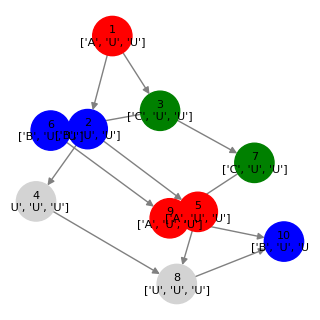

In [7]:
MAX_ITER = 10

for i in range(1, MAX_ITER + 1):
    updates, prev_opinion = directed_multi_opinion_step(G)
    trust_updates = dynamic_trust_step(G, prev_opinion)

    real_changes = {
        node: op for node, op in updates.items()
        if prev_opinion[node] != op
    }

    for (u, v), new_trust in trust_updates.items():
        G[u][v]["trust"] = new_trust

    print(
        f"Iteration {i}: {len(real_changes)} real opinion changes, "
        f"{len(trust_updates)} trust updates"
    )

    if not real_changes:
        print("No new opinion changes. Converged.")
        export_to_excel(G, i, prev_opinion)
        plot_iteration(G, i)
        break

    for node, op in real_changes.items():
        G.nodes[node]["opinion"] = op

    export_to_excel(G, i, prev_opinion)
    plot_iteration(G, i)